In [36]:
# ! pip install plotly networkx

In [37]:
# ! pip install -U kaleido

In [38]:
# ! pip install -U plotly

In [39]:
# Imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.io as pio
from collections import defaultdict
import matplotlib
import math
from plotly.colors import sample_colorscale

In [ ]:
# CHANGE HERE: Path to your INPUT file
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\combined_matrix_2lc.csv'

# CHANGE HERE: Path to your INPUT GROUPS file
groups_filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\cluster_groups_2lc.csv'

In [41]:
# Output directory for transition probablity matrices. Use .eps, the .png will be automatically created
transition_probability_matrix_output_dir = r'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps'
os.makedirs(transition_probability_matrix_output_dir, exist_ok=True)

# Output directory for transition probability graphs
transition_graph_output_dir = r"C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph"
os.makedirs(transition_graph_output_dir, exist_ok=True)

# Base output directory
transition_graph_top10_dir = r"C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\top_10_transition_probability_graph"
os.makedirs(transition_graph_top10_dir, exist_ok=True)

# Output directory for top 10 transition probability graphs
top10_output_dir = r'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph_top10'
os.makedirs(top10_output_dir, exist_ok=True)

**Function Definitions**

In [42]:
# Creates a dictionary of transitions that occur consecutively given a subset of the orignal data and the whole of the original data
def create_transitions( data , all_data , include_self_transitions = False ):
    transitions = {}
    indices = set(data.index)

    for i in range(len(all_data) - 1):
        current_idx = all_data.index[i]
        next_idx = all_data.index[i + 1]

        if current_idx in indices and next_idx in indices:
            cluster_from = all_data.loc[current_idx, 'Cluster']
            cluster_to = all_data.loc[next_idx, 'Cluster']
            transition = (cluster_from, cluster_to)

            if include_self_transitions:
                if transition in transitions:
                    transitions[transition] += 1
                else:
                    transitions[transition] = 1
            else:
                if cluster_from != cluster_to:
                    if transition in transitions:
                        transitions[transition] += 1
                    else:
                        transitions[transition] = 1
    
    return transitions

In [43]:
# Plot 1: Creates and plots transition probability matrix (heatmap) given a dictionary of transitions. Returns the transition probability matrix for further use. Roi is just used to title the figure. 
def plot_transition_matrix( transitions , title , save = False , path = None ):
    clusters = sorted(set([c for pair in transitions.keys() for c in pair]))
    transition_matrix = pd.DataFrame(0, index=clusters, columns=clusters)

    for (from_cluster, to_cluster), count in transitions.items():
        transition_matrix.loc[from_cluster, to_cluster] = count

    prob_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0).fillna(0)
    prob_matrix.index = clusters
    prob_matrix.columns = clusters

    plt.figure(figsize=(8, 7))

    ax = sns.heatmap(prob_matrix, cmap='Blues', cbar_kws={'label': 'Transition Probability'}, linewidths=1, linecolor=None)
    num_clusters = len(clusters)
    border = Rectangle((0, 0), num_clusters, num_clusters, fill=False, edgecolor='black')
    ax.add_patch(border)

    plt.xlabel('To Cluster')
    plt.ylabel('From Cluster')
    plt.title(f'{title} Cluster Transition Probability Matrix' )
    plt.tight_layout()

    if save:
        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")
    
    plt.show()

    return prob_matrix

In [44]:
# Plot 2 => utilizes color bar to show the weights of transitions as well as with the width of the edges
def create_interactive_transition_graph(
    transitions,
    title,
    min_weight_threshold=0.05,
    save=False,
    path=None,
    export_csv=False,
    csv_path=None
):
    G = nx.DiGraph()

    outgoing_totals = defaultdict(int)
    for (u, v), count in transitions.items():
        outgoing_totals[u] += count

    for (u, v), count in transitions.items():
        prob = count / outgoing_totals[u]
        if prob >= min_weight_threshold:
            G.add_edge(str(u), str(v), weight=prob)

    pos = nx.circular_layout(G)
    node_degrees = dict(G.degree())
    node_size = [deg * 2 + 10 for deg in node_degrees.values()]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=node_size,
            color='white',
            line=dict(width=2, color='black')
        ),
        textfont=dict(size=10, color='black')
    )

    weights = np.array([G[u][v]['weight'] for u, v in G.edges])
    norm_weights = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)

    def weight_to_color(w):
        return sample_colorscale('RdBu', w)[0]

    edge_traces = []
    for i, (u, v) in enumerate(G.edges):
        weight = G[u][v]['weight']
        color = weight_to_color(norm_weights[i])
        edge_traces.append(
            go.Scatter(
                x=[pos[u][0], pos[v][0], None],
                y=[pos[u][1], pos[v][1], None],
                line=dict(width=weight * 10, color=color),
                hoverinfo='none',
                mode='lines',
            )
        )

    edge_weight_trace = go.Scatter(
        x=[(pos[u][0] + pos[v][0]) / 2 for u, v in G.edges],
        y=[(pos[u][1] + pos[v][1]) / 2 for u, v in G.edges],
        text=[f'{G[u][v]["weight"]:.2f}' for u, v in G.edges],
        mode='text',
        hoverinfo='text',
        textfont=dict(size=8, color='black'),
    )

    # Colorbar trace (invisible markers with colorscale)
    colorbar_trace = go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(
            colorscale='RdBu',
            cmin=weights.min(),
            cmax=weights.max(),
            color=[weights.min(), weights.max()],
            colorbar=dict(
                title="Edge Weight",
                title_side="right",
                tickvals=np.linspace(weights.min(), weights.max(), num=5),
                ticks="outside",
                ticklen=5,
                thickness=15,
                len=0.5,
            ),
            showscale=True
        ),
        hoverinfo='none'
    )

    fig = go.Figure(data=[*edge_traces, node_trace, colorbar_trace])

    fig.update_layout(
        title={
            'text': f'{title} Probability Transition Graph',
            'font': {'size': 16}
        },
        width=1000,
        height=1000,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )

    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)

        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

        if export_csv:
            import csv
            node_sizes = {node: deg * 2 + 10 for node, deg in node_degrees.items()}

            with open(csv_path, mode='w', newline='') as csvfile:
                csvwriter = csv.writer(csvfile)
                csvwriter.writerow(['starting cluster', 'ending cluster', 'edge weight', 'node size'])
                for u, v in G.edges():
                    edge_weight = G[u][v]['weight']
                    node_size_u = node_sizes.get(u, 10)  # fallback to 10 if missing
                    csvwriter.writerow([u, v, edge_weight, node_size_u])

            print(f"CSV file '{csv_path}' created with {len(G.edges)} edges and {len(G.nodes)} nodes.")

    fig.show()


In [45]:
# # Plot 2 Alternative => plots all weights in black
# def create_interactive_transition_graph(transitions, title, min_weight_threshold=0.05 , save = False , path = None, export_csv=False, csv_path = None):
#     G = nx.DiGraph()
    
#     outgoing_totals = defaultdict(int)
#     for (u, v), count in transitions.items():
#         outgoing_totals[u] += count
    
#     for (u, v), count in transitions.items():
#         prob = count / outgoing_totals[u]
#         if prob >= min_weight_threshold:
#             G.add_edge(str(u), str(v), weight=prob)
    
#     pos = nx.circular_layout(G)
    
#     node_degrees = dict(G.degree())
#     node_size = [deg * 2 + 10 for deg in node_degrees.values()]
    
#     node_trace = go.Scatter(
#         x=[pos[node][0] for node in G.nodes],
#         y=[pos[node][1] for node in G.nodes],
#         text=[str(int(float(node))) for node in G.nodes],
#         mode='markers+text',
#         hoverinfo='text',
#         marker=dict(
#             size=node_size,
#             color='white',
#             line=dict(width=2, color='red')
#         ),
#         textfont=dict(size=10, color='black')
#     )
    
#     edge_traces = []
#     annotations = []
    
#     for u, v in G.edges:
#         weight = G[u][v]['weight']
#         edge_traces.append(
#         go.Scatter(
#             x=[pos[u][0], pos[v][0], None],
#             y=[pos[u][1], pos[v][1], None],
#             line=dict(width=weight * 10, color='black'),
#             hoverinfo='none',
#             mode='lines',
#         )
#         )
    
#     annotations.append(
#         dict(
#             ax=pos[u][0],
#             ay=pos[u][1],
#             x=pos[v][0],
#             y=pos[v][1],
#             xref='x', yref='y',
#             axref='x', ayref='y',
#             showarrow=True,
#             arrowhead=2,
#             arrowsize=1,
#             arrowwidth=1,
#             arrowcolor='black',
#         )
#     )
    
#     edge_weight_trace = go.Scatter(
#         x=[(pos[u][0] + pos[v][0]) / 2 for u, v in G.edges],
#         y=[(pos[u][1] + pos[v][1]) / 2 for u, v in G.edges],
#         text=[f'{G[u][v]["weight"]:.2f}' for u, v in G.edges],
#         mode='text',
#         hoverinfo='text',
#         textfont=dict(size=8, color='black'),
#     )
    
#     fig = go.Figure(data=[*edge_traces, node_trace])
    
#     fig.update_layout(
#         title={
#         'text': f'{title} Probability Transition Graph',
#         'font': {'size': 16}
#         },
#         width=1000,
#         height=1000,
#         showlegend=False,
#         hovermode='closest',
#         margin=dict(b=0, l=0, r=0, t=40),
#         xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
#         yaxis=dict(
#             scaleanchor="x",
#             scaleratio=1,
#             showgrid=False,
#             zeroline=False,
#             showticklabels=False,
#         ),
#     )
    
#     if save and path:
#         base_path, ext = os.path.splitext(path)
#         os.makedirs(os.path.dirname(base_path), exist_ok=True)
        
#         fig.write_image(f"{base_path}.png")
#         fig.write_image(f"{base_path}.svg")
        
#         if export_csv:
#             import csv
#             # Create a mapping from nodes to their calculated sizes
#             node_degrees = dict(G.degree())
#             node_sizes = {node: deg * 2 + 10 for node, deg in node_degrees.items()}
        
#             with open(csv_path, mode='w', newline='') as csvfile:
#                 csvwriter = csv.writer(csvfile)
#                 csvwriter.writerow(['starting cluster', 'ending cluster', 'edge weight', 'node size'])
#                 for u, v in G.edges():
#                     edge_weight = G[u][v]['weight']
#                     node_size_u = node_sizes.get(u, 10) # fallback to 10 if missing
#                     csvwriter.writerow([u, v, edge_weight, node_size_u])
        
#             print(f"CSV file '{csv_path}' created with {len(G.edges)} edges and {len(G.nodes)} nodes.")
    
    
#     fig.show()

In [46]:
# Plot 3: Creates and plots an interactive transition graph given a transition probability matrix. All other parameters are used for visualization purposes
# Only the top 10 transitions with the highest probability are shown, for clarity purposes. This creates a directed graph. Excludes self transitions.

def plot_transition_graph(subset_transition_matrix, cluster_groups, nodes = 10, transitions=10, node_scaling=15, edge_scaling=15, text_scaling=3, arrow_reduction_factor = 0.05 , title="Transition Graph" , save = False , path = None , export_csv = False , csv_path = None):
    edges = []
   
    for i in subset_transition_matrix.index:
        for j in subset_transition_matrix.columns:
            weight = subset_transition_matrix.loc[i, j]
            if weight > 0 and i != j:
                edges.append((str(i), str(j), weight))  

    top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:transitions]
    top_nodes = set([u for u, v, w in top_edges] + [v for u, v, w in top_edges])

    G = nx.DiGraph()
    G.add_nodes_from(top_nodes)

    for u, v, w in top_edges:
        G.add_edge(u, v, weight=w)

    pos = nx.circular_layout(G)

    node_degrees = dict(G.degree())
    node_size = [degree * node_scaling + 10 for degree in node_degrees.values()]
    text_size = [degree * text_scaling + 10 for degree in node_degrees.values()]

    pixel_to_coord = 2.4 / 800
    node_radius = [size * pixel_to_coord * 0.5 for size in node_size]
    node_radii = {node: r for node, r in zip(G.nodes, node_radius)}
    arrow_length_reduction = 0.03

    group_colors = matplotlib.colormaps["tab20"].resampled(21) 

    node_colors = []
    for node in G.nodes:
        cluster_num = int(float(node))
        group = cluster_to_group.get(cluster_num, 0)  # 0 if not found
        color = plt.cm.tab10(group % 10)
        node_colors.append(color)


    node_colors_hex = ['#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255)) for r, g, b, a in node_colors]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=node_size,
            color=node_colors_hex,
            line=dict(width=3, color='black')
        ),
        textfont=dict(
            size=text_size,
            color='black'
        )
    )

    edge_traces = []
    arrow_length_reduction = 0.1  

    for u, v in G.edges:
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_weight = G[u][v]['weight']

        dx = x1 - x0
        dy = y1 - y0
        dist = np.sqrt(dx*dx + dy*dy)

        if dist == 0:
            continue 

        offset_u = node_radii[u]
        offset_v = node_radii[v]

        total_offset = offset_u + offset_v + arrow_length_reduction

        shrink_factor = total_offset / dist if dist > total_offset else 0

        x_start = x0 + dx * (offset_u / dist)
        y_start = y0 + dy * (offset_u / dist)

        x_end = x1 - dx * (offset_v / dist) - dx * arrow_length_reduction
        y_end = y1 - dy * (offset_v / dist) - dy * arrow_length_reduction

        edge_traces.append(
            go.Scatter(
                x=[x_start, x_end, None],
                y=[y_start, y_end, None],
                line=dict(
                    width=edge_weight * edge_scaling,
                    color='black'
                ),
                hoverinfo='none',
                mode='lines',
            )
        )

    fig = go.Figure(data=[*edge_traces, node_trace])

    for u, v in G.edges:
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        dx = x1 - x0
        dy = y1 - y0
        dist = (dx**2 + dy**2)**0.5

        if dist > 0:
            x1_arrow = x1 - dx * arrow_reduction_factor
            y1_arrow = y1 - dy * arrow_reduction_factor
        else:
            x1_arrow, y1_arrow = x1, y1

        fig.add_annotation(
            ax=x0,
            ay=y0,
            x=x1_arrow,
            y=y1_arrow,
            xref='x',
            yref='y',
            axref='x',
            ayref='y',
            showarrow=True,
            arrowhead=2,
            arrowsize=(edge_scaling/12),
            arrowwidth=edge_weight*edge_scaling,
            arrowcolor='black'
        )

        
    # Update layout and display
    fig.update_layout(
        title={
            'text': title,
            'font': {'size': 16}
        },
        width=800,
        height=800,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(
            range=[-1.2, 1.2],
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
        yaxis=dict(
            range=[-1.2, 1.2],
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )

    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)

        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    # Export CSV section
    if export_csv:
        import csv
        
        node_degrees = dict(G.degree())
        node_sizes = {node: degree * node_scaling + 10 for node, degree in node_degrees.items()}
        
        with open(csv_path, mode='w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(['starting cluster', 'ending cluster', 'edge weight', 'node size'])
            
            for u, v, w in top_edges:
                node_size_u = node_sizes.get(u, 10)
                csvwriter.writerow([u, v, w, node_size_u])
        
        print(f"CSV file '{csv_path}' has been created with {len(top_edges)} edges.")



    fig.show() 

In [47]:
# Plot 4

def create_interactive_transition_graph_from_csv(csv_path, title, save=False, path=None):
    def create_pos_in_order(G):
        # Sort nodes numerically by their cluster numbers for ordered circular layout
        try:
            nodes_sorted = sorted(G.nodes, key=lambda x: int(float(x)))
        except Exception:
            nodes_sorted = sorted(G.nodes)
        
        n = len(nodes_sorted)
        pos = {}
        for i, node in enumerate(nodes_sorted):
            angle = 2 * math.pi * i / n
            pos[node] = (math.cos(angle), math.sin(angle))
        return pos

    transitions_df = pd.read_csv(csv_path)

    # Sort descending by edge weight and get top 10 transitions
    top_10_df = transitions_df.sort_values(by='edge weight', ascending=False).head(10)

    # Create directed graph
    G = nx.DiGraph()

    # Add edges and node sizes as per CSV
    for _, row in transitions_df.iterrows():
        u = str(row['starting cluster'])
        v = str(row['ending cluster'])
        weight = row['edge weight']
        G.add_edge(u, v, weight=weight)

    # Store node sizes from CSV (max size among edges connecting to node)
    node_sizes = {}
    for _, row in transitions_df.iterrows():
        u = str(row['starting cluster'])
        size = row['node size']
        node_sizes[u] = max(size, node_sizes.get(u, 0))
    for _, row in transitions_df.iterrows():
        v = str(row['ending cluster'])
        size = row['node size']
        node_sizes[v] = max(size, node_sizes.get(v, 0))

    # Use custom ordered circular layout for node positions
    pos = create_pos_in_order(G)

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=[node_sizes.get(node, 10) for node in G.nodes],
            color='white',
            line=dict(width=2, color='red')
        ),
        textfont=dict(size=10, color='black')
    )

    edge_traces = []
    annotations = []

    # Create a set of top 10 edges for quick lookup
    top_10_edges = set((str(row['starting cluster']), str(row['ending cluster'])) for _, row in top_10_df.iterrows())

    for u, v in G.edges:
        weight = G[u][v]['weight']
        color = 'black' if (u, v) in top_10_edges else 'lightgray'
        edge_traces.append(
            go.Scatter(
                x=[pos[u][0], pos[v][0], None],
                y=[pos[u][1], pos[v][1], None],
                line=dict(width=weight * 10, color=color),
                hoverinfo='none',
                mode='lines',
            )
        )
        annotations.append(
            dict(
                ax=pos[u][0],
                ay=pos[u][1],
                x=pos[v][0],
                y=pos[v][1],
                xref='x', yref='y',
                axref='x', ayref='y',
                showarrow=True,
                arrowhead=2,
                arrowsize=1,
                arrowwidth=1,
                arrowcolor=color,
            )
        )

    fig = go.Figure(data=[*edge_traces, node_trace])
    fig.update_layout(
        title={
            'text': f'{title} Probability Transition Graph',
            'font': {'size': 16}
        },
        width=1000,
        height=1000,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )

    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    fig.show()


**Analysis**

In [48]:
clusters_data = pd.read_csv( filename , index_col=0 )
clusters_data

arena_cluster_groups = pd.read_csv( groups_filename , index_col= 0 )
cluster_to_group = dict(zip(arena_cluster_groups['Cluster'], arena_cluster_groups['Group']))

In [49]:
# clusters_data_week1 = clusters_data[clusters_data['Week_Number'] == 8 ]
# clusters_data_week3 = clusters_data[clusters_data['Week_Number'] == 10 ]
# clusters_data_week6 = clusters_data[clusters_data['Week_Number'] == 12 ]


week_dfs = {
    f"week{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in clusters_data.groupby("Week_Number", sort=True)
}

week_dfs["all"] = clusters_data.sort_values(by="Cluster", ascending=True).copy()

In [50]:
week_dfs.keys()

dict_keys(['week8', 'week10', 'week12', 'week14', 'week18', 'all'])

In [51]:
week_transitions = {
    name: create_transitions(df, clusters_data)
    for name, df in week_dfs.items()
}

week_transitions.keys()

dict_keys(['week8', 'week10', 'week12', 'week14', 'week18', 'all'])

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps\week8_transition_probability_matrix.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\png\week8_transition_probability_matrix.png


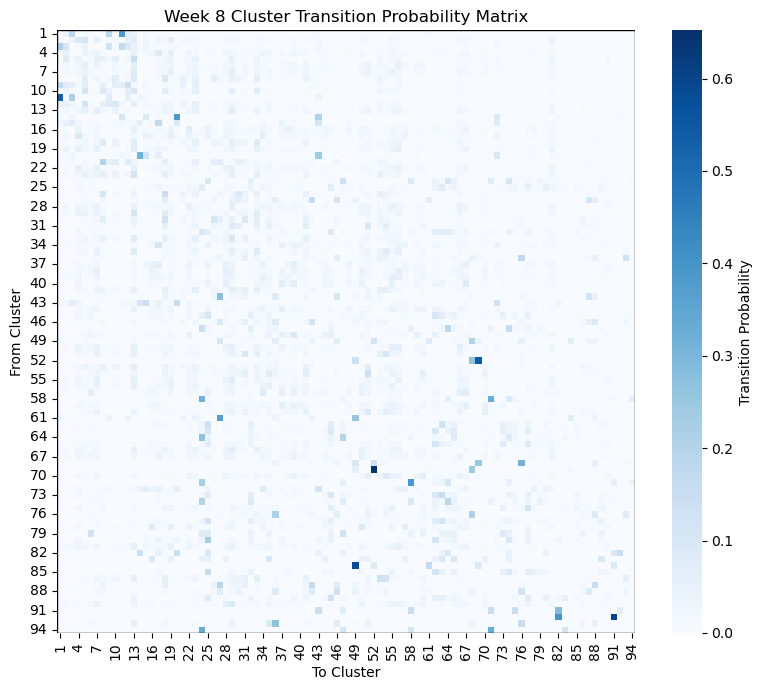

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps\week10_transition_probability_matrix.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\png\week10_transition_probability_matrix.png


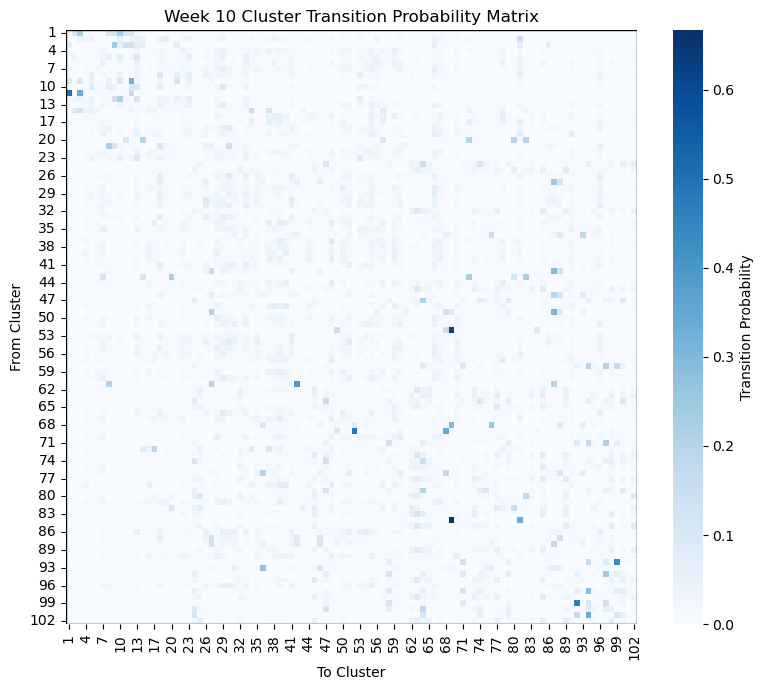

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps\week12_transition_probability_matrix.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\png\week12_transition_probability_matrix.png


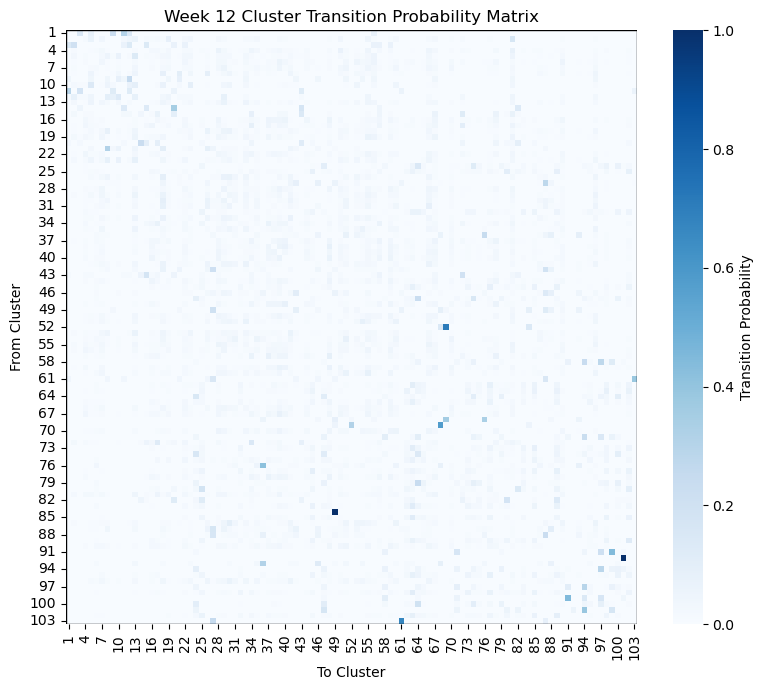

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps\week14_transition_probability_matrix.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\png\week14_transition_probability_matrix.png


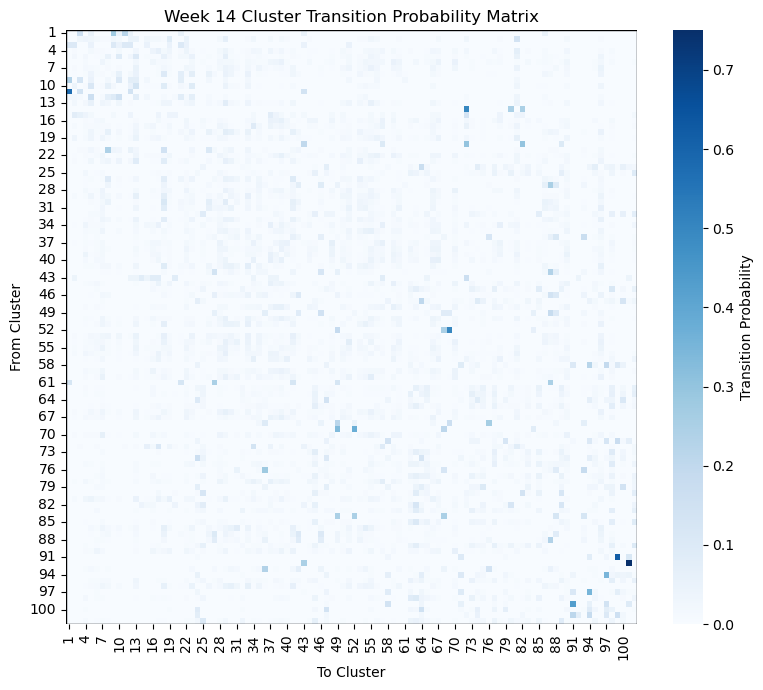

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps\week18_transition_probability_matrix.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\png\week18_transition_probability_matrix.png


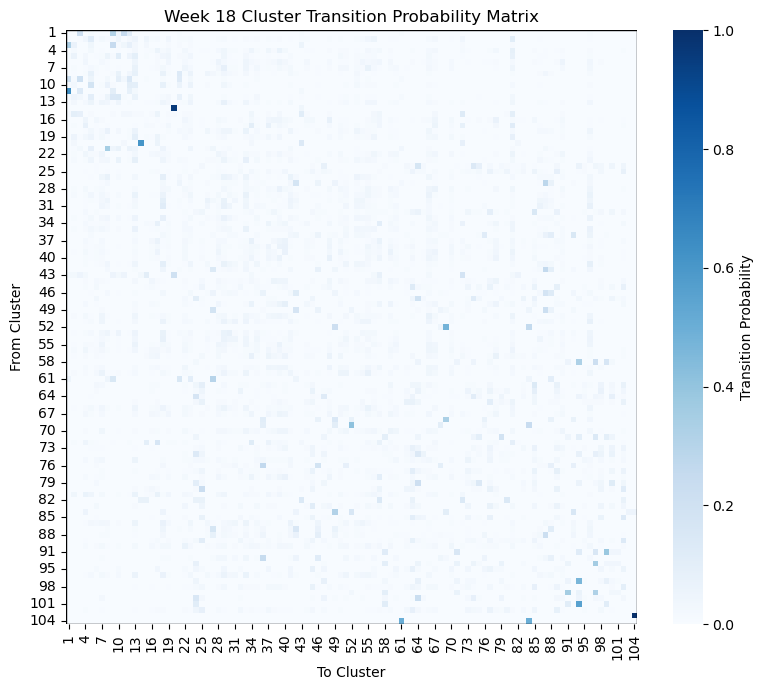

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\eps\all_transition_probability_matrix.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_matrix\png\all_transition_probability_matrix.png


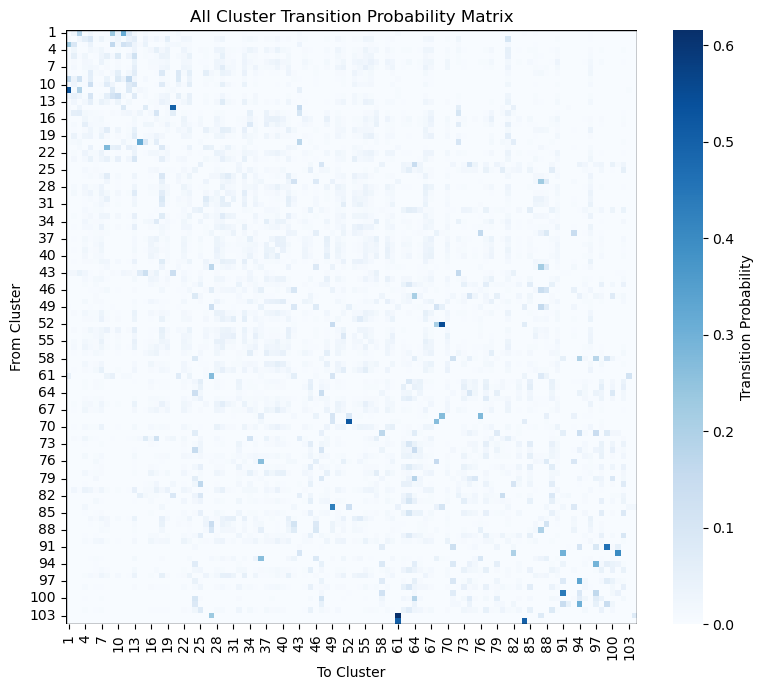

In [52]:
transition_matrices = {}

paths = [
    os.path.join(
        transition_probability_matrix_output_dir,
        f"{name}_transition_probability_matrix.eps"
    )
    for name in week_transitions.keys()  
]

for (name, transitions_df), save_path in zip(week_transitions.items(), paths):
    if name == "all":
        title_str = "All"
    else:
        title_str = name.replace("week", "Week ")
    
    # Plot and save
    returned_matrix = plot_transition_matrix(
        transitions_df,
        title=title_str,
        save=True,
        path=save_path
    )
    
    transition_matrices[name] = returned_matrix

In [53]:
csv_paths = {}

for name, transitions_df in week_transitions.items():
    # Generate title
    title_str = "All Weeks" if name == "all" else name.replace("week", "Week ")

    # Create paths for saving
    save_dir = os.path.join(transition_graph_output_dir, name)
    os.makedirs(save_dir, exist_ok=True)

    base_filename = "transition_probability_graph"
    fig_path = os.path.join(save_dir, base_filename) 
    csv_path = os.path.join(save_dir, f"{name}_edges.csv")


    fig = create_interactive_transition_graph(
        transitions_df,
        title=title_str,
        save=True,
        path=fig_path,
        export_csv=True,
        csv_path=csv_path
    )

    csv_paths[name] = csv_path


for name, path in csv_paths.items():
    print(f"{name}: {path}")


CSV file 'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week8\week8_edges.csv' created with 441 edges and 94 nodes.


CSV file 'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week10\week10_edges.csv' created with 426 edges and 99 nodes.


CSV file 'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week12\week12_edges.csv' created with 444 edges and 103 nodes.


CSV file 'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week14\week14_edges.csv' created with 434 edges and 102 nodes.


CSV file 'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week18\week18_edges.csv' created with 473 edges and 103 nodes.


CSV file 'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\all\all_edges.csv' created with 403 edges and 98 nodes.


week8: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week8\week8_edges.csv
week10: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week10\week10_edges.csv
week12: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week12\week12_edges.csv
week14: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week14\week14_edges.csv
week18: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\week18\week18_edges.csv
all: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\transition_probability_graph\all\all_edges.csv


In [54]:
# Loop through all items
for name, matrix in transition_matrices.items():
    # Generate title
    title_str = "All Weeks Transition Graph" if name == "all" else f"Week {name.replace('week','')} Transition Graph"
    
    # Build directory for saving
    save_dir = os.path.join(transition_graph_top10_dir, name)
    os.makedirs(save_dir, exist_ok=True)
    
    # Build base path for figure
    base_filename = "top10_transition_probability_graph"
    fig_path = os.path.join(save_dir, base_filename)
    
    # Build CSV path
    csv_path = os.path.join(save_dir, f"{name}_edges_top10.csv")
    
    # Call the plotting function
    plot_transition_graph(
        matrix,
        None,
        edge_scaling=10,
        text_scaling=6,
        arrow_reduction_factor=0.045,
        title=title_str,
        save=True,         
        path=fig_path,     
        export_csv=False,   
        csv_path=csv_path
    )
    

In [55]:
for name, csv_path in csv_paths.items():
    title_str = "All Weeks" if name == "all" else name.replace("week", "Week ")

    save_dir = os.path.join(top10_output_dir, name)
    os.makedirs(save_dir, exist_ok=True)

    base_filename = f"top10_{name}_transition_probability_graph"
    save_path = os.path.join(save_dir, base_filename)

    create_interactive_transition_graph_from_csv(
        csv_path=csv_path,
        title=title_str,
        save=True,  
        path=save_path
    )